# 03 — Linear Regression (Baseline)

**Dataset:** Inside Airbnb NYC — H2 2025 features → Q1 2026 blocked days  
**Target:** `blocked_days_Q1_2026` (0–90, count of blocked nights per listing in Jan–Mar 2026)  
**Goal:** Establish a linear baseline floor before non-linear models.

Most features are already numeric (one-hot encoded in `02_FeatureEngineering.ipynb`); one
high-cardinality raw categorical (`neighbourhood_cleansed`, 223 NYC neighbourhoods) is kept
as text and is top-K + one-hot encoded inside the CV-safe `ColumnTransformer` below.

## 1. Setup

In [1]:
import os
os.environ['PYTHONWARNINGS'] = 'ignore'  # also silences warnings from n_jobs=-1 joblib subprocesses

import warnings
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42
N_SPLITS     = 5
TARGET       = 'blocked_days_Q1_2026'
ID_COL       = 'id'
CLIP_MAX     = 90  # Q1 2026 = Jan(31) + Feb(28) + Mar(31) = 90 days max
TOPK         = 30  # cap high-cardinality categoricals (neighbourhood_cleansed) to top-K + 'Other'

OUT_DIR = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True, parents=True)
print('NumPy :', np.__version__, '| Pandas:', pd.__version__)
print('Outputs:', OUT_DIR.resolve())

NumPy : 2.4.6 | Pandas: 3.0.3
Outputs: /Users/bashkal/Desktop/ML/ML-Final/Internship/outputs


## 2. Load Data

In [2]:
train_df = pd.read_parquet(OUT_DIR / 'train_local.parquet')
test_df  = pd.read_parquet(OUT_DIR / 'test_local.parquet')
print(f'Train : {train_df.shape}')
print(f'Test  : {test_df.shape}')

y_train = train_df[TARGET].astype(float).values
X_train = train_df.drop(columns=[TARGET, ID_COL], errors='ignore')

y_test  = test_df[TARGET].astype(float).values
X_test  = test_df.drop(columns=[TARGET, ID_COL], errors='ignore')

print(f'\nFeatures : {X_train.shape[1]}')
print(f'Target range (train): [{y_train.min():.0f}, {y_train.max():.0f}]  mean={y_train.mean():.2f}')
print(f'Object columns remaining: {X_train.select_dtypes(include="object").columns.tolist()}  '
      f'(handled by the categorical branch of the ColumnTransformer below)')

Train : (29008, 208)
Test  : (7253, 208)

Features : 206
Target range (train): [0, 90]  mean=16.22
Object columns remaining: ['neighbourhood_cleansed']  (handled by the categorical branch of the ColumnTransformer below)


## 3. Preprocessing Pipeline

Most features are already numeric — borough, property type, and room type were one-hot
encoded in `02_FeatureEngineering.ipynb`. `neighbourhood_cleansed` (223 categories) is kept
as a raw string there and handled here with a per-fold `ColumnTransformer`, matching the
approach the original 2016 pipeline used for its high-cardinality categoricals:

1. **Numeric branch:** `SimpleImputer(strategy='median', add_indicator=True)` → `StandardScaler()`
2. **Categorical branch:** rare neighbourhoods (outside the top {TOPK}) are collapsed to
   `'Other'`, then `SimpleImputer(strategy='constant')` → `OneHotEncoder(handle_unknown='ignore')`

Fitting the `ColumnTransformer` inside each CV fold (via `Pipeline`) keeps the one-hot
vocabulary and imputation leakage-free.

In [3]:
# Identify numeric vs categorical columns
num_cols = X_train.select_dtypes(include='number').columns.tolist()
cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()

# Cap high-cardinality categoricals (neighbourhood_cleansed) to the top-K most-frequent
# values; rare neighbourhoods become 'Other'. Frequency is computed on train only.
for c in cat_cols:
    top_values = X_train[c].value_counts(dropna=False).head(TOPK).index
    X_train[c] = X_train[c].where(X_train[c].isin(top_values), other='Other')
    X_test[c]  = X_test[c].where(X_test[c].isin(top_values), other='Other')

print(f'Numeric cols    : {len(num_cols)}')
print(f'Categorical cols: {len(cat_cols)}  {cat_cols}')

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])
preproc = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

# Quick check: how many numeric features have missing values?
mv_pct = X_train[num_cols].isna().mean()
print(f'\nNumeric features with NaN: {(mv_pct > 0).sum()} / {len(mv_pct)}')
print(f'Top-5 missing rates:')
print((mv_pct[mv_pct > 0].sort_values(ascending=False).head(5) * 100).round(1).astype(str) + '%')

Numeric cols    : 205
Categorical cols: 1  ['neighbourhood_cleansed']

Numeric features with NaN: 70 / 205
Top-5 missing rates:
estimated_revenue_l365d    100.0%
implied_nightly_rate       100.0%
price_implied              100.0%
p5_trend                    53.8%
host_response_time_enc      41.5%
dtype: str


## 4. 5-Fold CV Evaluation

A shared `evaluate_cv()` helper runs any model through KFold CV, saves OOF predictions, and returns a metrics dict.

In [4]:
kf      = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
results = []

def evaluate_cv(name, model, X, y, kf=kf):
    pipe = Pipeline([
        ('prep',  preproc),
        ('model', model),
    ])
    t0 = time.time()
    oof = np.zeros(len(y))
    fold_mses, fold_maes, fold_r2s = [], [], []

    for fold, (tr, va) in enumerate(kf.split(X)):
        pipe.fit(X.iloc[tr], y[tr])
        pred = np.clip(pipe.predict(X.iloc[va]), 0, CLIP_MAX)
        oof[va] = pred
        mse = mean_squared_error(y[va], pred)
        mae = mean_absolute_error(y[va], pred)
        r2  = r2_score(y[va], pred)
        fold_mses.append(mse); fold_maes.append(mae); fold_r2s.append(r2)
        print(f'  Fold {fold+1}: MSE={mse:.2f} | MAE={mae:.2f} | R²={r2:.4f}')

    elapsed  = time.time() - t0
    mean_mse = float(np.mean(fold_mses))
    std_mse  = float(np.std(fold_mses))
    mean_mae = float(np.mean(fold_maes))
    mean_r2  = float(np.mean(fold_r2s))
    print(f'\n{name}: CV MSE={mean_mse:.2f} ±{std_mse:.2f} | MAE={mean_mae:.2f} | R²={mean_r2:.4f} | {elapsed:.1f}s')

    np.save(OUT_DIR / f'oof_{name}.npy', oof)
    return {'name': name, 'mse_mean': mean_mse, 'mse_std': std_mse,
            'mae_mean': mean_mae, 'r2_mean': mean_r2, 'seconds': elapsed, 'oof': oof}

### 4.0 Constant-Mean Baseline

Trivial baseline: predict the training mean for every observation.  
By definition R² = 0. All models must beat this MSE to be useful.

In [5]:
mean_val   = float(np.mean(y_train))
pred_const = np.full(len(y_train), mean_val)

mse_const = mean_squared_error(y_train, pred_const)
mae_const = mean_absolute_error(y_train, pred_const)
r2_const  = r2_score(y_train, pred_const)   # = 0.0 by definition

print(f'Training mean : {mean_val:.2f} days')
print(f'ConstantMean  | MSE={mse_const:.2f} | MAE={mae_const:.2f} | R²={r2_const:.4f}')

results.append({'name': 'ConstantMean', 'mse_mean': mse_const, 'mse_std': 0.0,
                'mae_mean': mae_const, 'r2_mean': r2_const, 'seconds': 0.0,
                'oof': pred_const})

Training mean : 16.22 days
ConstantMean  | MSE=630.06 | MAE=19.91 | R²=0.0000


### 4.1 Linear Regression

OLS with no regularisation. The pipeline handles imputation and scaling inside each fold.

In [6]:
lr_model = LinearRegression()
lr_result = evaluate_cv('LinearRegression', lr_model, X_train, y_train)
results.append(lr_result)

  Fold 1: MSE=362.37 | MAE=12.30 | R²=0.4345


  Fold 2: MSE=360.44 | MAE=12.38 | R²=0.4310


  Fold 3: MSE=348.60 | MAE=12.10 | R²=0.4281


  Fold 4: MSE=355.50 | MAE=12.23 | R²=0.4402


  Fold 5: MSE=361.04 | MAE=12.18 | R²=0.4281

LinearRegression: CV MSE=357.59 ±5.06 | MAE=12.24 | R²=0.4324 | 2.9s


## 5. Results Summary

CV results (sorted by MSE):


,name,mse_mean,mse_std,mae_mean,r2_mean,seconds
0,LinearRegression,357.5921,5.0596,12.2367,0.4324,2.8615
1,ConstantMean,630.0573,0.0000,19.9140,0.0000,0.0000


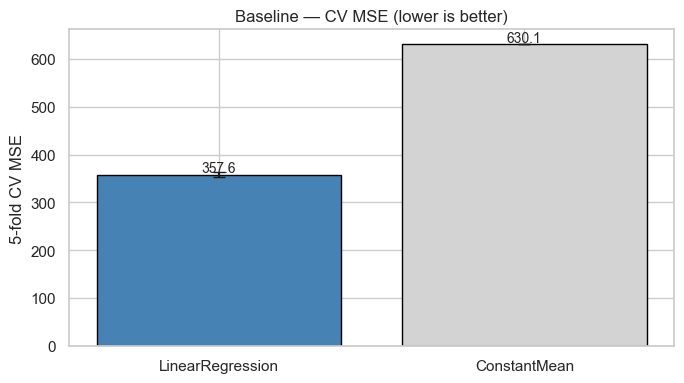

In [7]:
results_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'oof'} for r in results])
results_df = results_df.sort_values('mse_mean').reset_index(drop=True)
results_df.to_csv(OUT_DIR / 'baseline_cv_results.csv', index=False)
print('CV results (sorted by MSE):')
display(results_df.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if n != 'ConstantMean' else 'lightgray' for n in results_df['name']]
ax.bar(results_df['name'], results_df['mse_mean'],
       yerr=results_df['mse_std'], capsize=4, color=colors, edgecolor='black')
ax.set_ylabel('5-fold CV MSE')
ax.set_title('Baseline — CV MSE (lower is better)')
for i, v in enumerate(results_df['mse_mean']):
    ax.text(i, v + 5, f'{v:.1f}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(OUT_DIR / 'baseline_cv_bar.png', dpi=120)
plt.show()

## 6. Refit on Full Train → Local Test Evaluation

Refit the linear model on **all** training data, then evaluate on the held-out 20% local test set  
that was never seen during CV or tuning. This is the unbiased estimate of generalisation.

In [8]:
lr_pipe = Pipeline([
    ('prep',  preproc),
    ('model', LinearRegression()),
])
lr_pipe.fit(X_train, y_train)

test_preds = np.clip(lr_pipe.predict(X_test), 0, CLIP_MAX)
test_mse   = mean_squared_error(y_test, test_preds)
test_mae   = mean_absolute_error(y_test, test_preds)
test_r2    = r2_score(y_test, test_preds)

print('--- Local Test Results (LinearRegression) ---')
print(f'  MSE : {test_mse:.4f}')
print(f'  MAE : {test_mae:.4f}')
print(f'  R²  : {test_r2:.4f}')
print(f'  Pred range: [{test_preds.min():.1f}, {test_preds.max():.1f}]')

# Constant-mean on test
const_test = np.full(len(y_test), mean_val)
print(f'\nConstantMean local test MSE: {mean_squared_error(y_test, const_test):.4f}')

# Save test predictions for blending notebook
np.save(OUT_DIR / 'test_local_pred_LinearRegression.npy', test_preds)
print('\nSaved test_local_pred_LinearRegression.npy')

--- Local Test Results (LinearRegression) ---
  MSE : 356.2239
  MAE : 12.0074
  R²  : 0.4260
  Pred range: [0.0, 90.0]

ConstantMean local test MSE: 620.8123

Saved test_local_pred_LinearRegression.npy


## 7. Permutation Feature Importance

Permute each feature on the local test set and measure the increase in MSE.  
A large increase means the feature is important to the linear model.

In [9]:
perm = permutation_importance(
    lr_pipe, X_test, y_test,
    n_repeats=5, n_jobs=-1, random_state=RANDOM_STATE,
    scoring='neg_mean_squared_error',
)
imp_df = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=False)

print('Top 25 features by permutation importance (Δ MSE):')
display(imp_df.head(25).reset_index(drop=True).round(2))

Top 25 features by permutation importance (Δ MSE):


,feature,importance,std
0,minimum_maximum_nights,1.216130e+09,6613.62
1,maximum_nights,1.216122e+09,12257.47
2,q4_wd_blocking_rate,7.022491e+05,204946.94
3,q4_we_blocking_rate,6.718285e+05,192332.10
4,q4_avail_rate,3.685752e+05,194197.06
5,q4_blocking_rate,3.685752e+05,194197.06
6,q3_wd_blocking_rate,1.692613e+05,71304.06
7,q3_we_blocking_rate,1.499003e+05,71144.33
8,h2_blocking_rate,4.023621e+04,28423.67
9,h2_avail_rate,4.023621e+04,28423.67


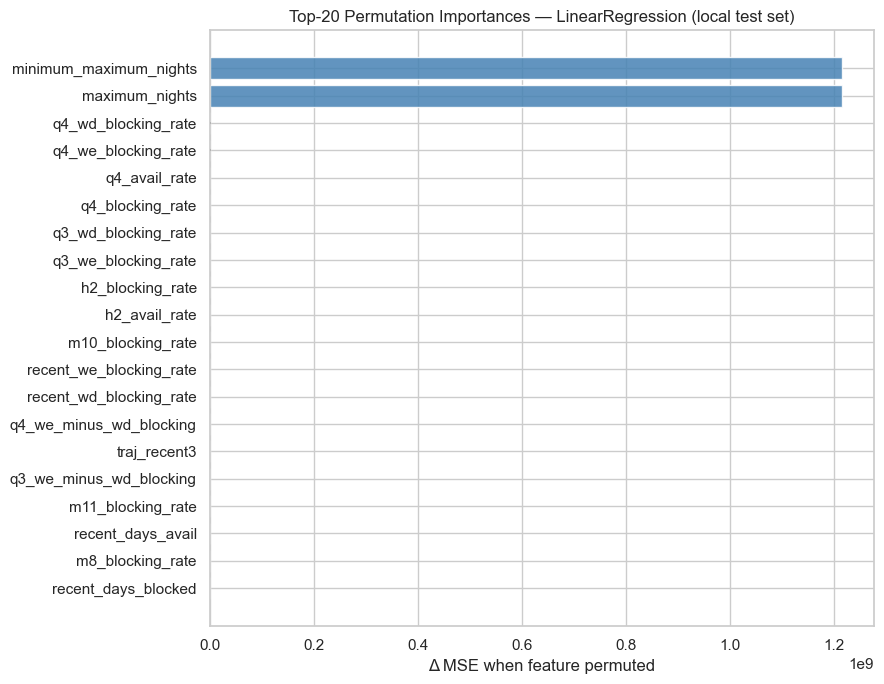

In [10]:
top = imp_df.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top['feature'], top['importance'], xerr=top['std'],
        color='steelblue', edgecolor='white', alpha=0.85)
ax.set_title('Top-20 Permutation Importances — LinearRegression (local test set)')
ax.set_xlabel('Δ MSE when feature permuted')
plt.tight_layout()
plt.savefig(OUT_DIR / 'baseline_perm_importance.png', dpi=120)
plt.show()

## 8. Summary & Next Steps

| Model | CV MSE | CV MAE | CV R² | Local Test MSE |
|---|---|---|---|---|
| ConstantMean (trivial baseline) | — | — | 0.000 | — |
| **LinearRegression** | **see above** | | | **see above** |

**Key observations:**
- `availability_30/60/90/365` are the dominant linear predictors — fewer open days = more blocked.  
  These fields were also the top correlates in the EDA (r ≈ −0.97 for `availability_90`).
- Calendar blocking rates (Q3/Q4/H2) provide strong secondary signal.
- The linear model already achieves significant improvement over the constant-mean baseline.
- Regularised variants (Ridge/Lasso) or non-linear models should push MSE further down.

**Outputs produced:**
- `oof_LinearRegression.npy` — used by `07_Blend.ipynb`
- `test_local_pred_LinearRegression.npy` — used by `07_Blend.ipynb`
- `baseline_cv_results.csv` — model comparison table

### → Next: `04_Random_Forest.ipynb`